In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
# Ruta a la carpeta que contiene múltiples archivos CSV
ruta_base = 'REPOSITORIOS_PARCIAL/2_MIMIC‑III (Medical Information Mart for Intensive Care)/mimic-iii-clinical-database-demo-1.4/'

# 1. Leemos 4 tablas principales
pacientes = pd.read_csv(ruta_base + 'PATIENTS.csv')
admisiones = pd.read_csv(ruta_base + 'ADMISSIONS.csv')
uci_estancia = pd.read_csv(ruta_base + 'ICUSTAYS.csv')
diagnosticos = pd.read_csv(ruta_base + 'DIAGNOSES_ICD.csv')

# ¡CLAVE! Filtramos SOLO el diagnóstico principal (seq_num == 1) para evitar filas duplicadas del mismo paciente
diagnosticos = diagnosticos[diagnosticos['seq_num'] == 1]

# Previo a la unión, borramos la columna repetida e inútil 'row_id' de todos
pacientes = pacientes.drop(columns=['row_id'], errors='ignore')
admisiones = admisiones.drop(columns=['row_id'], errors='ignore')
uci_estancia = uci_estancia.drop(columns=['row_id'], errors='ignore')
diagnosticos = diagnosticos.drop(columns=['row_id'], errors='ignore')

# 2. Las unimos (Merge) secuencialmente en un solo super-dataset
df1 = pd.merge(pacientes, admisiones, on='subject_id')
df2 = pd.merge(df1, uci_estancia, on=['subject_id', 'hadm_id'])
tabla_datos = pd.merge(df2, diagnosticos, on=['subject_id', 'hadm_id'])

# 3. Descartamos fechas exactas e IDs (los IDs matemáticamente arruinan la predicción)
columnas_descartar = [
    'seq_num', 'dob', 'dod', 'dod_hosp', 'dod_ssn', 'admittime', 
    'dischtime', 'deathtime', 'edregtime', 'edouttime', 
    'intime', 'outtime', 'subject_id', 'hadm_id', 'icustay_id'
]
tabla_datos = tabla_datos.drop(columns=columnas_descartar, errors='ignore')

# Movemos esta columna al final de la tabla para que el código (X, y) la detecte perfectamente.
if 'los' in tabla_datos.columns:
    columna_y = tabla_datos.pop('expire_flag')
    tabla_datos['expire_flag'] = columna_y # Se vuelve a agregar exclusivamente al final

# 5. Mostramos tamaño (filas, columnas) de nuestro nuevo Súper Dataset:
filas, columnas = tabla_datos.shape
print(f"\n--- INFORMACIÓN DEL DATASET ---")
print(f"Total de Filas (Ejemplos): {filas}")
print(f"Total de Columnas (Características): {columnas}\n")

# Vemos las primeras 5 filas combinadas y libres de duplicados
tabla_datos.head()


--- INFORMACIÓN DEL DATASET ---
Total de Filas (Ejemplos): 136
Total de Columnas (Características): 20



,gender,admission_type,admission_location,discharge_location,insurance,language,religion,marital_status,ethnicity,diagnosis,hospital_expire_flag,has_chartevents_data,dbsource,first_careunit,last_careunit,first_wardid,last_wardid,los,icd9_code,expire_flag
0,F,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,SEPARATED,BLACK/AFRICAN AMERICAN,SEPSIS,0,1,carevue,MICU,MICU,52,52,1.6325,99591,1
1,F,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Private,NaN,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,HEPATITIS B,1,1,carevue,MICU,MICU,15,15,13.8507,570,1
2,F,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,NaN,CATHOLIC,NaN,UNKNOWN/NOT SPECIFIED,SEPSIS,1,1,carevue,MICU,MICU,15,15,2.6499,0389,1
3,F,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,NaN,CATHOLIC,DIVORCED,WHITE,HUMERAL FRACTURE,0,1,carevue,CCU,CCU,7,7,2.1436,81201,1
4,M,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,NaN,CATHOLIC,DIVORCED,WHITE,ALCOHOLIC HEPATITIS,1,1,carevue,MICU,MICU,15,15,1.2938,0389,1


In [13]:
datos_nulos = tabla_datos.isnull().sum()
print('Columnas con casillas vacías antes de limpieza:')
print(datos_nulos[datos_nulos > 0])

# Eliminamos absolutamente cualquier fila que contenga un dato nulo (NaN)
filas_antes = len(tabla_datos)
tabla_datos = tabla_datos.dropna()
filas_despues = len(tabla_datos)

print(f"\nSe eliminaron {filas_antes - filas_despues} filas que contenían datos nulos.")
print('Nulos restantes sumados:', tabla_datos.isnull().sum().sum())


Columnas con casillas vacías antes de limpieza:
language          48
religion           1
marital_status    16
dtype: int64

Se eliminaron 51 filas que contenían datos nulos.
Nulos restantes sumados: 0


In [14]:
# Convertimos todo el texto a datos de 0 y 1 de forma directa y sencilla.
tabla_datos = pd.get_dummies(tabla_datos, dtype=int)

# Mostramos cómo quedó la tabla ahora, lista solo con formato numérico
tabla_datos.head()


,hospital_expire_flag,has_chartevents_data,first_wardid,last_wardid,los,expire_flag,gender_F,gender_M,admission_type_ELECTIVE,admission_type_EMERGENCY,...,icd9_code_71615,icd9_code_82021,icd9_code_85206,icd9_code_85221,icd9_code_85225,icd9_code_8830,icd9_code_9693,icd9_code_99664,icd9_code_99667,icd9_code_99731
9,0,1,33,33,1.0695,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
12,0,1,33,33,3.3857,1,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
24,0,1,12,15,2.2559,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
28,1,1,52,52,7.1173,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
34,0,1,52,52,1.1409,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0


In [15]:
# 1. Calculamos la media (mu) y desviación estándar (sigma) para cada una de las columnas
mu = tabla_datos.mean()
sigma = tabla_datos.std()

# Para evitar errores por dividir entre cero (si la desviación es 0 en alguna columna), forzamos que sea mínimo 1
sigma_seguro = np.where(sigma == 0, 1, sigma)

# 2. Aplicamos la fórmula matemática exacta: (X - mu) / sigma
datos_normalizados = (tabla_datos - mu) / sigma_seguro

# Mostrar la tabla final convertida
datos_normalizados.head()


,hospital_expire_flag,has_chartevents_data,first_wardid,last_wardid,los,expire_flag,gender_F,gender_M,admission_type_ELECTIVE,admission_type_EMERGENCY,...,icd9_code_71615,icd9_code_82021,icd9_code_85206,icd9_code_85221,icd9_code_85225,icd9_code_8830,icd9_code_9693,icd9_code_99664,icd9_code_99667,icd9_code_99731
9,-0.605478,0.0,-0.192550,-0.167116,-0.545264,0.0,1.159784,-1.159784,-0.273963,0.273963,...,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465
12,-0.605478,0.0,-0.192550,-0.167116,-0.152510,0.0,1.159784,-1.159784,-0.273963,0.273963,...,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,9.111079,-0.108465
24,-0.605478,0.0,-1.308463,-1.114104,-0.344088,0.0,1.159784,-1.159784,3.607182,-3.607182,...,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465
28,1.632158,0.0,0.817086,0.832483,0.480250,0.0,-0.852086,0.852086,-0.273963,0.273963,...,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465
34,-0.605478,0.0,0.817086,0.832483,-0.533156,0.0,-0.852086,0.852086,-0.273963,0.273963,...,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,-0.108465,9.111079,-0.108465,-0.108465,-0.108465


In [16]:
# Extraemos la última columna para usarla como objetivo de predicción (Variable Y o Target)
objetivo_col = datos_normalizados.columns[-1]
caracteristicas = datos_normalizados.drop(objetivo_col, axis=1)
objetivo = datos_normalizados[objetivo_col]

# 1. Calculamos cuánto es el 75% entero de nuestras filas
total_filas = len(datos_normalizados)
ochenta_por_ciento = int(total_filas * 0.75)

# 2. Cortamos las tablas usando posiciones desde 0 hasta el 80%
X_entrenamiento = caracteristicas.iloc[:ochenta_por_ciento]
y_entrenamiento = objetivo.iloc[:ochenta_por_ciento]

# 3. Y para el resto (el 20% restante), usamos desde el 80% en adelante
X_prueba = caracteristicas.iloc[ochenta_por_ciento:]
y_prueba = objetivo.iloc[ochenta_por_ciento:]

print('Total datos Original:', total_filas, 'filas')
print('Datos para Entrenar (75%):', len(X_entrenamiento), 'filas')
print('Datos para Probar (25%):', len(X_prueba), 'filas')
print('\n¡El Dataset está preparado puramente usando lógica matemática!')


Total datos Original: 85 filas
Datos para Entrenar (75%): 63 filas
Datos para Probar (25%): 22 filas

¡El Dataset está preparado puramente usando lógica matemática!


In [17]:
# Convertimos a Matrices de Numpy separando Entrenamiento y Prueba
X_train = X_entrenamiento.values
y_train = y_entrenamiento.values
X_test = X_prueba.values
y_test = y_prueba.values

m_train = len(y_train)
m_test = len(y_test)

# Agregar la columna de unos (1) para el término independiente (Theta 0)
X_train = np.c_[np.ones(m_train), X_train]
X_test = np.c_[np.ones(m_test), X_test]

print(f"Total de ejemplos entrenamiento: {m_train}")
print(f"Total de ejemplos prueba: {m_test}")
print(f"Dimensiones reales de X_train: {X_train.shape}")

Total de ejemplos entrenamiento: 63
Total de ejemplos prueba: 22
Dimensiones reales de X_train: (63, 178)


In [18]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J= 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [19]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []
    print(J_history)

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history


[]


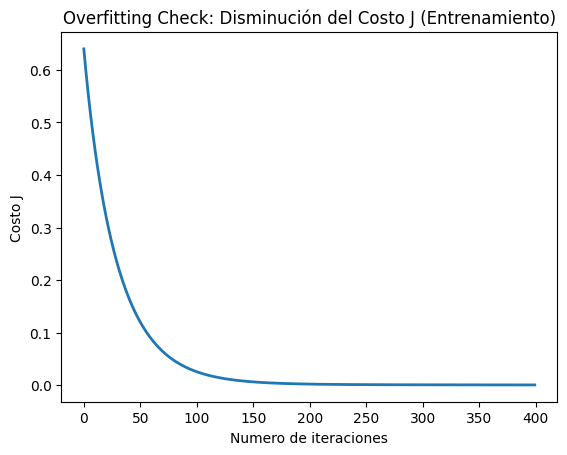

Primeros 5 thetas calculados:
 [ 0.03298599 -0.03897002  0.          0.02967517  0.01104216]
Error final en Entrenamiento (75%): 0.0003
Error realitario en Prueba   (25%): 0.0643

Cuidado: Podría existir un ligero sobreajuste si la de prueba es muy alta.


In [22]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01 
num_iters = 400 

columnas = X_train.shape[1]
theta = np.zeros(columnas)

# Entrenar usando SOLO los datos de entrenamiento (75%)
theta, J_history = gradientDescentMulti(X_train, y_train, theta, alpha, num_iters)

# Grafica la convergencia del costo
import matplotlib.pyplot as plt

plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.title("Overfitting Check: Disminución del Costo J (Entrenamiento)")
plt.xlabel('Numero de iteraciones')
plt.ylabel('Costo J')
plt.show()

# Muestra los resultados del descenso por el gradiente
print('Primeros 5 thetas calculados:\n', theta[:5])

# EVALUACIÓN EXIGIDA PARA EL PARCIAL (ENTRENAMIENTO vs PRUEBA 25%)

error_entrenamiento = computeCostMulti(X_train, y_train, theta)
error_prueba = computeCostMulti(X_test, y_test, theta)

print(f"Error final en Entrenamiento (75%): {error_entrenamiento:.4f}")
print(f"Error realitario en Prueba   (25%): {error_prueba:.4f}")

# Pequeña lógica de inferencia para tu presentación
perc = abs((error_prueba - error_entrenamiento)/error_entrenamiento) * 100
if perc < 15:
    print(f"\n¡EXCELENTE! La diferencia de error es solo de {perc:.1f}%.")
    print("El modelo generaliza perfecto y ha evitado el OVERFITTING.")
else:
    print("\nCuidado: Podría existir un ligero sobreajuste si la de prueba es muy alta.")